<a href="https://colab.research.google.com/github/Rory41/Breast-Cancer-Detection-Using-Yolov9-Model/blob/main/busbra_codes_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import pathlib
import ast
from typing import Tuple, List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F_torch
from torch.utils.data import DataLoader, Dataset, random_split

from torchvision.transforms import v2
import torchvision.transforms.v2.functional as F_vision
from torchvision.io import decode_image
from torchvision.utils import save_image
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

print("All imports successful")

All imports successful


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
img_dir = "/content/drive/MyDrive/BUSBRA/Original Images"
mask_dir = "/content/drive/MyDrive/BUSBRA/Original Masks"

In [ ]:
# Set the CSV file path
csv_path = "/content/drive/MyDrive/BUSBRA/bus_data.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(csv_path)

# Display the first few rows to confirm
print(f"Loaded {len(df)} records from CSV.")

Loaded 1875 records from CSV.


In [ ]:
import pandas as pd

# Load original CSV
csv_path = "/content/drive/MyDrive/BUSBRA/bus_data.csv"
df = pd.read_csv(csv_path)

print("Original class distribution:")
print(df['Pathology'].value_counts())

# Downsample benign to match malignant
df_benign = df[df['Pathology'] == 'benign'].sample(n=607, random_state=42)
df_malignant = df[df['Pathology'] == 'malignant']

# Replace df with balanced version
df = pd.concat([df_benign, df_malignant], ignore_index=True)
df = df.sample(frac=1.0, random_state=42)  # Shuffle

print("\nBalanced class distribution:")
print(df['Pathology'].value_counts())

# Save updated CSV (same variable, new location)
df.to_csv("/content/drive/MyDrive/BUSBRA/balanced_bus_data.csv", index=False)
print("\nBalanced CSV saved to /content/drive/MyDrive/BUSBRA/bus_data.csv")

Original class distribution:
Pathology
benign       1268
malignant     607
Name: count, dtype: int64

Balanced class distribution:
Pathology
malignant    607
benign       607
Name: count, dtype: int64

Balanced CSV saved to /content/drive/MyDrive/BUSBRA/bus_data.csv


In [ ]:
df.head(10)

,ID,Case,Histology,Pathology,BIRADS,Device,Width,Height,Side,BBOX
739,bus_0256-r,256,invasive ductal carcinoma,malignant,4,GE Logiq 7 @10-14MHz,275,349,right,"[69,61,135,98]"
788,bus_0310-r,310,invasive ductal carcinoma,malignant,5,GE Logiq 7 @10-14MHz,276,351,right,"[123,65,104,85]"
43,bus_0296-l,296,fibroadenoma,benign,2,GE Logiq 7 @10-14MHz,273,381,left,"[56,89,83,39]"
155,bus_0804-s,804,fibroadenoma,benign,4,GE Logiq 5 @10-12MHz,565,468,single,"[89,51,369,208]"
494,bus_1012-r,1012,fibroadenoma,benign,4,Toshiba Aplio 300 @12-14 MHz,276,306,right,"[109,62,65,36]"
969,bus_0585-r,585,invasive ductal carcinoma,malignant,4,GE Logiq 5 @10-12MHz,322,459,right,"[26,26,137,94]"
270,bus_1061-r,1061,fibroadenoma,benign,3,Toshiba Aplio 300 @12-14 MHz,277,306,right,"[138,67,37,24]"
590,bus_0372-l,372,fibroadenoma,benign,2,GE Logiq 5 @10-12MHz,320,426,left,"[76,40,123,60]"
123,bus_0975-l,975,fibroadenoma,benign,4,GE Logiq 7 @10-14MHz,274,352,left,"[71,69,127,49]"
113,bus_0621-r,621,fibroadenoma,benign,3,GE Logiq 5 @10-12MHz,269,399,right,"[72,64,95,78]"


In [ ]:
df.columns

Index(['ID', 'Case', 'Histology', 'Pathology', 'BIRADS', 'Device', 'Width',
       'Height', 'Side', 'BBOX'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1214 entries, 739 to 1126
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         1214 non-null   object
 1   Case       1214 non-null   int64 
 2   Histology  1214 non-null   object
 3   Pathology  1214 non-null   object
 4   BIRADS     1214 non-null   int64 
 5   Device     1214 non-null   object
 6   Width      1214 non-null   int64 
 7   Height     1214 non-null   int64 
 8   Side       1214 non-null   object
 9   BBOX       1214 non-null   object
dtypes: int64(4), object(6)
memory usage: 104.3+ KB


In [ ]:
df.BBOX

,BBOX
739,"[69,61,135,98]"
788,"[123,65,104,85]"
43,"[56,89,83,39]"
155,"[89,51,369,208]"
494,"[109,62,65,36]"
...,...
1044,"[235,103,124,81]"
1095,"[92,37,132,84]"
1130,"[62,36,140,121]"
860,"[24,55,236,195]"


In [ ]:
# Check the type of the first BBOX entry
print(type(df['BBOX'].iloc[0]))  # Should be <class 'str'> if not yet converted

# Convert BBOX column from string to list
df['BBOX'] = df['BBOX'].apply(ast.literal_eval)

# Confirm the conversion
print(type(df['BBOX'].iloc[0]))  # Should now be <class 'list'>
print(df['BBOX'].head())

<class 'str'>
<class 'list'>
739     [69, 61, 135, 98]
788    [123, 65, 104, 85]
43       [56, 89, 83, 39]
155    [89, 51, 369, 208]
494     [109, 62, 65, 36]
Name: BBOX, dtype: object


In [ ]:
df.BBOX

,BBOX
739,"[69, 61, 135, 98]"
788,"[123, 65, 104, 85]"
43,"[56, 89, 83, 39]"
155,"[89, 51, 369, 208]"
494,"[109, 62, 65, 36]"
...,...
1044,"[235, 103, 124, 81]"
1095,"[92, 37, 132, 84]"
1130,"[62, 36, 140, 121]"
860,"[24, 55, 236, 195]"


In [ ]:


def data_walk_through(img_dir, mask_dir):
    """
    Walks through the image and mask directories,
    collects all .png file paths, and returns them as sorted lists.
    """
    # Find all PNG files in the image directory
    img_list = sorted(glob.glob(os.path.join(img_dir, "*.png")))

    # Find all PNG files in the mask directory
    mask_list = sorted(glob.glob(os.path.join(mask_dir, "*.png")))

    return img_list, mask_list

In [ ]:
import os

# Get all image and mask paths
img_list, mask_list = data_walk_through(img_dir, mask_dir)

# Build a mapping from filename (without .png) to full path
img_map = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in img_list
}

mask_map = {
    'bus_' + os.path.splitext(os.path.basename(p).replace("mask_", ""))[0]: p
    for p in mask_list
}

# Now assign paths by matching df['ID'] to filename stems
df['Image_path'] = df['ID'].astype(str).map(img_map)
df['Mask_path'] = df['ID'].astype(str).map(mask_map)

# Display results
print(f"Mapped {df['Image_path'].notna().sum()} image paths")
print(f"Mapped {df['Mask_path'].notna().sum()} mask paths")
print(f"DataFrame now has {len(df.columns)} columns")

# Show a few rows
df[['ID', 'Pathology', 'Image_path', 'Mask_path']].head()


Mapped 1214 image paths
Mapped 1214 mask paths
DataFrame now has 12 columns


,ID,Pathology,Image_path,Mask_path
739,bus_0256-r,malignant,/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
788,bus_0310-r,malignant,/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
43,bus_0296-l,benign,/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
155,bus_0804-s,benign,/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
494,bus_1012-r,benign,/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...


In [ ]:
# Display the first few actual mapped file paths
print("\nSample mapped entries (Image vs. Mask):\n")
for i in range(5):
    print(f"{i+1}. Image: {df.loc[i, 'Image_path']}")
    print(f"   Mask : {df.loc[i, 'Mask_path']}")
    print("-" * 60)



Sample mapped entries (Image vs. Mask):

1. Image: /content/drive/MyDrive/BUSBRA/Original Images/bus_1003-r.png
   Mask : /content/drive/MyDrive/BUSBRA/Original Masks/mask_1003-r.png
------------------------------------------------------------
2. Image: /content/drive/MyDrive/BUSBRA/Original Images/bus_0625-r.png
   Mask : /content/drive/MyDrive/BUSBRA/Original Masks/mask_0625-r.png
------------------------------------------------------------
3. Image: /content/drive/MyDrive/BUSBRA/Original Images/bus_0348-r.png
   Mask : /content/drive/MyDrive/BUSBRA/Original Masks/mask_0348-r.png
------------------------------------------------------------
4. Image: /content/drive/MyDrive/BUSBRA/Original Images/bus_0813-s.png
   Mask : /content/drive/MyDrive/BUSBRA/Original Masks/mask_0813-s.png
------------------------------------------------------------
5. Image: /content/drive/MyDrive/BUSBRA/Original Images/bus_0629-r.png
   Mask : /content/drive/MyDrive/BUSBRA/Original Masks/mask_0629-r.png
----

In [ ]:
print("\nDuplicate image paths:", df['Image_path'].duplicated().sum())
print("Duplicate mask paths :", df['Mask_path'].duplicated().sum())



Duplicate image paths: 0
Duplicate mask paths : 0


In [ ]:
df = df.drop(['Case', 'BIRADS', 'Device', "Width", 'Height'], axis=1)
df.head()

,ID,Histology,Pathology,Side,BBOX,Image_path,Mask_path
739,bus_0256-r,invasive ductal carcinoma,malignant,right,"[69, 61, 135, 98]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
788,bus_0310-r,invasive ductal carcinoma,malignant,right,"[123, 65, 104, 85]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
43,bus_0296-l,fibroadenoma,benign,left,"[56, 89, 83, 39]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
155,bus_0804-s,fibroadenoma,benign,single,"[89, 51, 369, 208]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
494,bus_1012-r,fibroadenoma,benign,right,"[109, 62, 65, 36]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...


In [ ]:
# Plot through the series training set
def plot_images(dframe):
    n_rows, n_cols = 3, 2

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(8,12))

    for i in range(3):
        selector = np.random.choice(len(dframe))  # Randomly pick an index

        img_path = dframe.iloc[selector].Image_path  # Correct DataFrame indexing
        mask_path = dframe.iloc[selector].Mask_path
        # print(img_path)
        # print(mask_path)

        img = Image.open(img_path)
        mask = Image.open(mask_path)

        axs[i, 0].imshow(img, cmap='gray')
        axs[i, 0].set_title(dframe.iloc[selector].Pathology)
        axs[i, 0].axis('off')

        axs[i, 1].imshow(mask)
        axs[i, 1].set_title(dframe.iloc[selector].Pathology)
        axs[i, 1].axis('off')


    plt.tight_layout()
    plt.show()

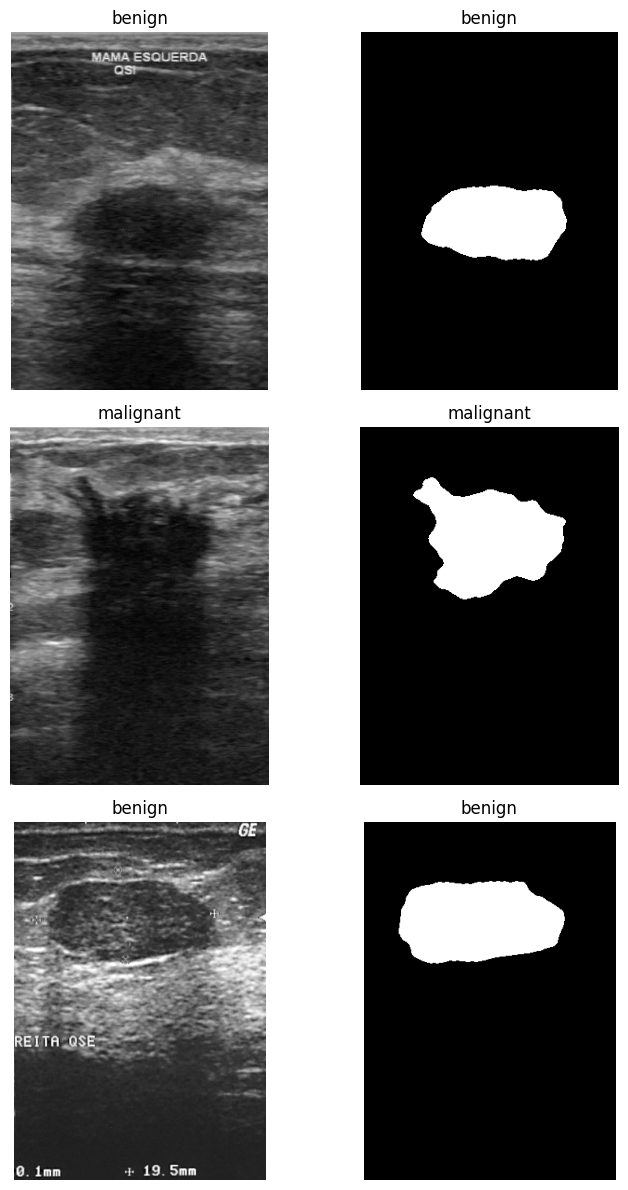

In [ ]:
plot_images(df)

## Explore the data

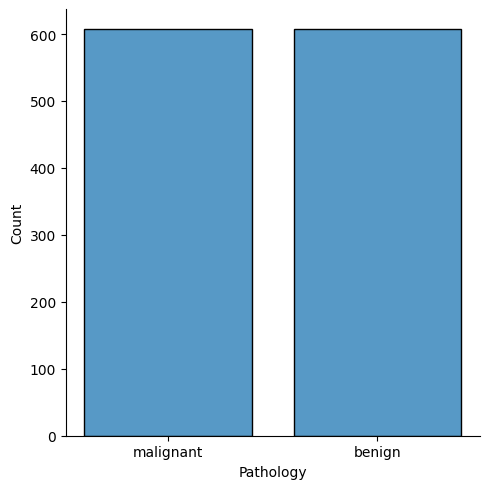

In [ ]:
sns.displot(df, x="Pathology", shrink=.8)

In [ ]:
df['Pathology'].value_counts()

,count
Pathology,
malignant,607
benign,607


In [ ]:
df['Side'].value_counts()

,count
Side,
right,533
left,521
single,160


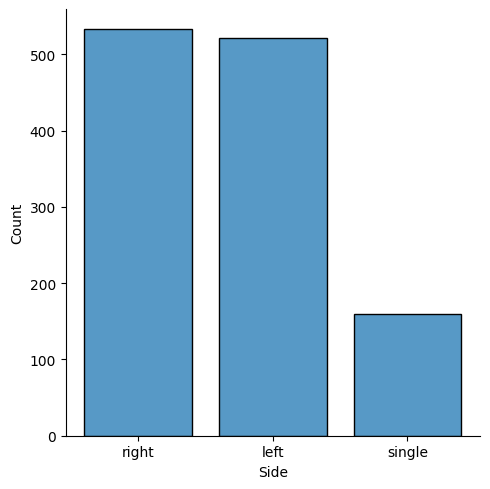

In [ ]:
sns.displot(df, x="Side", shrink=.8)

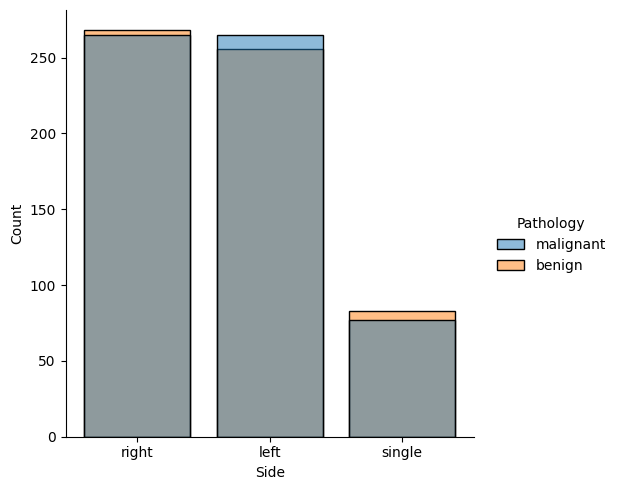

In [ ]:
sns.displot(df, x="Side", shrink=.8, hue='Pathology')

# DataLoder

In [ ]:

class CustomImageDataset(Dataset):
    def __init__(self, df, transform=None, target_transform=None, class_map={'benign': 0, 'malignant': 1}):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.target_transform = target_transform
        self.class_map = class_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row.Image_path
        mask_path = row.Mask_path
        bbox = row.BBOX
        label = self.class_map[row.Pathology]

        # Load image and mask
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # Ensure mask is single channel

        w, h = img.size

        # Validate and convert bbox
        if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
            raise ValueError(f"Invalid bbox format at index {idx}: {bbox}")

        x_min, y_min, bw, bh = map(float, bbox)

        # Convert to YOLO format [class, x_center, y_center, norm_w, norm_h]
        x_center = (x_min + bw / 2) / w
        y_center = (y_min + bh / 2) / h
        norm_bw = bw / w
        norm_bh = bh / h

        yolo_box = torch.tensor([label, x_center, y_center, norm_bw, norm_bh], dtype=torch.float32)

        # Apply transforms
        if self.transform:
            img = self.transform(img)
        if self.target_transform:
            mask = self.target_transform(mask)

        return img, mask, yolo_box

In [ ]:
ds = CustomImageDataset(df)

In [ ]:
img, mask, _ = ds[10]

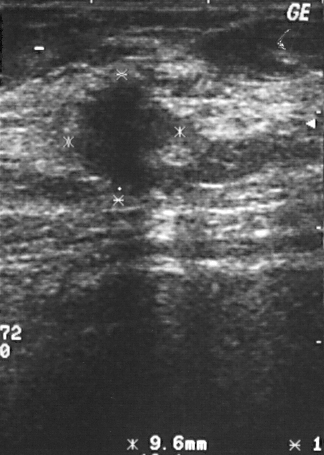

In [ ]:
img

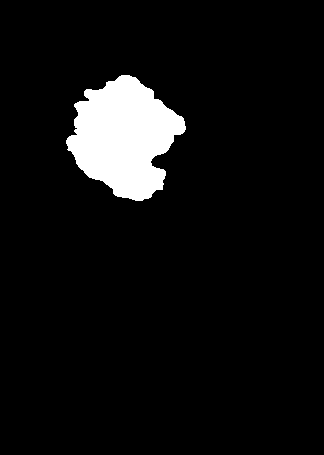

In [ ]:
mask

In [ ]:
len(ds)

1214

In [ ]:
print(img.size, img.format, img.mode)
print(mask.size, mask.format, img.mode)

(324, 455) None RGB
(324, 455) None RGB


# Augmentation

In [ ]:
df.head(5)

,ID,Histology,Pathology,Side,BBOX,Image_path,Mask_path
739,bus_0256-r,invasive ductal carcinoma,malignant,right,"[69, 61, 135, 98]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
788,bus_0310-r,invasive ductal carcinoma,malignant,right,"[123, 65, 104, 85]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
43,bus_0296-l,fibroadenoma,benign,left,"[56, 89, 83, 39]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
155,bus_0804-s,fibroadenoma,benign,single,"[89, 51, 369, 208]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...
494,bus_1012-r,fibroadenoma,benign,right,"[109, 62, 65, 36]",/content/drive/MyDrive/BUSBRA/Original Images/...,/content/drive/MyDrive/BUSBRA/Original Masks/m...


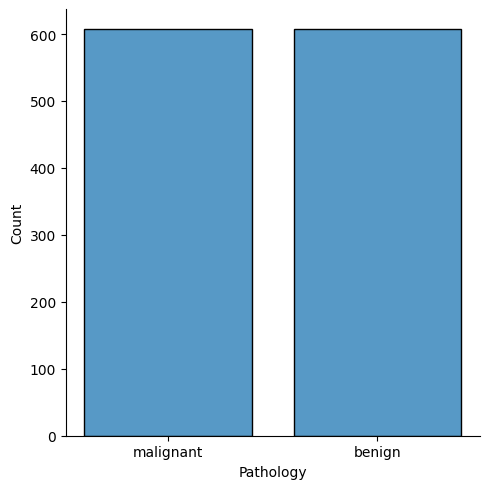

In [ ]:
sns.displot(df, x="Pathology", shrink=.8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1214 entries, 739 to 1126
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          1214 non-null   object
 1   Histology   1214 non-null   object
 2   Pathology   1214 non-null   object
 3   Side        1214 non-null   object
 4   BBOX        1214 non-null   object
 5   Image_path  1214 non-null   object
 6   Mask_path   1214 non-null   object
dtypes: object(7)
memory usage: 108.2+ KB


In [ ]:
df.columns

Index(['ID', 'Histology', 'Pathology', 'Side', 'BBOX', 'Image_path',
       'Mask_path'],
      dtype='object')

# Transforms

In [ ]:

class RandomContrast:
    def __init__(self, contrast_range=(0.5, 0.95)):
        self.contrast_range = contrast_range

    def __call__(self, image):
        factor = np.random.uniform(*self.contrast_range)
        return F.adjust_contrast(image, factor)

In [ ]:


class RandomContrast:
    def __init__(self, contrast_range=(0.5, 1.5)):
        """
        Random contrast adjustment transform.

        Args:
            contrast_range (tuple): Range for contrast adjustment (lower, upper).
                   Values < 1.0 reduce contrast, > 1.0 increase contrast.
                   Default (0.5, 1.5) provides both reduction and enhancement.
        """
        # Validate input range
        if contrast_range[0] >= contrast_range[1]:
            raise ValueError("contrast_range should be (min, max) where min < max")
        if contrast_range[0] <= 0:
            raise ValueError("contrast_range values must be positive")

        self.contrast_range = contrast_range

    def __call__(self, image):
        """
        Args:
            image (PIL.Image or torch.Tensor): Input image

        Returns:
            Image with adjusted contrast
        """
        # Handle both PIL Images and tensors
        if not isinstance(image, (Image.Image, torch.Tensor)):
            raise TypeError(f"Input should be PIL Image or torch.Tensor. Got {type(image)}")

        factor = np.random.uniform(*self.contrast_range)
        return F.adjust_contrast(image, factor)

    def __repr__(self):
        return f"{self.__class__.__name__}(contrast_range={self.contrast_range})"

In [ ]:
# Updated make_normalizer that handles various batch formats
def make_normalizer(dataloader, img_index=0):
    n_pixels = 0
    total = 0.0
    total_sq = 0.0

    with torch.no_grad():
        for batch in dataloader:
            # Flexible batch handling
            imgs = batch[img_index] if isinstance(batch, (list, tuple)) else batch
            imgs = imgs.float()

            b, c, h, w = imgs.shape
            imgs_flat = imgs.view(b, c, -1)

            n_pixels += imgs_flat.size(0) * imgs_flat.size(2)
            total += imgs_flat.sum(dim=[0, 2])
            total_sq += (imgs_flat ** 2).sum(dim=[0, 2])

    mean = total / n_pixels
    std = (total_sq / n_pixels - mean ** 2).sqrt()

    print(f"Dataset Mean: {mean.tolist()}, Std: {std.tolist()}")
    return v2.Normalize(mean=mean.tolist(), std=std.tolist())

In [ ]:
# Make a temporary loader to load the dataset and get the normalizer
temp_composer = v2.Compose([
    v2.ToImage(),  # Convert to tensor first
    v2.Resize(size=(256, 256), antialias=True),
    v2.ToDtype(torch.float32, scale=True),  # Normalizes to [0,1] if scale=True
])

# Create temporary dataset - removed asterisk (*) which was causing unpacking error
temp_ds = CustomImageDataset(df, transform=temp_composer, target_transform=temp_composer)
print(len(temp_ds))

# Create DataLoader - added shuffle=False for consistent normalization stats
temp_loader = DataLoader(temp_ds, batch_size=32, shuffle=False)
print(temp_loader)

# Get normalizer
normalizer = make_normalizer(temp_loader)

# Final composer with proper ordering of transforms
composer = v2.Compose([
    v2.ToImage(),  # Should be first to convert PIL to tensor
    v2.Resize(256),
    RandomContrast(),  # Apply contrast before normalization
    v2.ToDtype(torch.float32, scale=True),  # Keep scale=True to maintain [0,1] range
    normalizer,  # Normalize last (after all pixel manipulations)
])

1214
Dataset Mean: [0.3218582570552826, 0.3218582570552826, 0.3218582570552826], Std: [0.19245626032352448, 0.19245626032352448, 0.19245626032352448]


In [ ]:
print(normalizer)

Normalize(mean=[0.3218582570552826, 0.3218582570552826, 0.3218582570552826], std=[0.19245626032352448, 0.19245626032352448, 0.19245626032352448], inplace=False)


Returned items count: 3
Types: [<class 'torchvision.tv_tensors._image.Image'>, <class 'torchvision.tv_tensors._image.Image'>, <class 'torch.Tensor'>]
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])


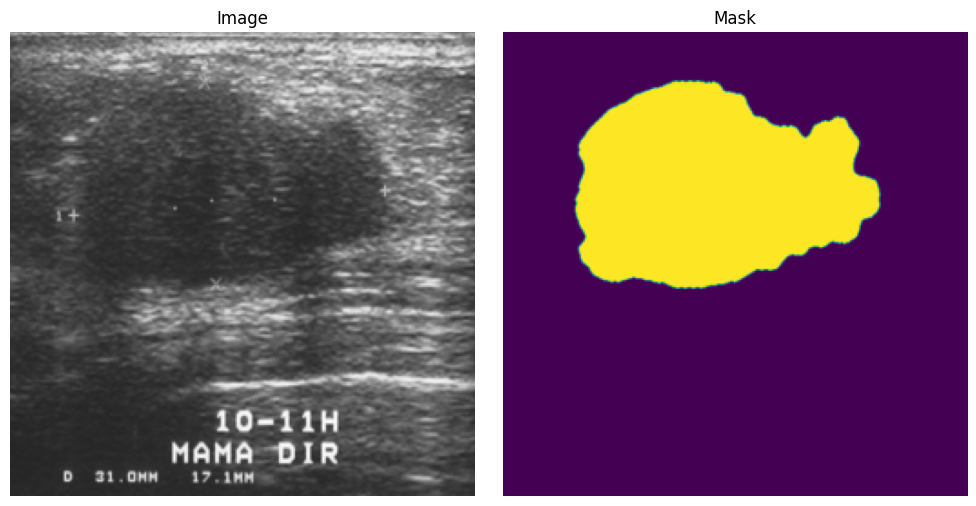

In [ ]:
# Safe way to inspect dataset items
sample = temp_ds[3]  # Get the complete sample first

# Check what's actually being returned
print(f"Returned items count: {len(sample) if isinstance(sample, (tuple, list)) else 1}")
print(f"Types: {[type(x) for x in sample] if isinstance(sample, (tuple, list)) else type(sample)}")

# Handle different return cases
if isinstance(sample, (tuple, list)):
    if len(sample) >= 2:
        img, mask = sample[0], sample[1]  # Explicitly get first two elements
        print(f"Image shape: {img.shape if hasattr(img, 'shape') else 'N/A'}")
        print(f"Mask shape: {mask.shape if hasattr(mask, 'shape') else 'N/A'}")

        # Visualize with no axes
        plt.figure(figsize=(10,5))

        # Image plot
        plt.subplot(1,2,1)
        plt.imshow(img.permute(1,2,0) if isinstance(img, torch.Tensor) else img)
        plt.title("Image")
        plt.axis('off')  # This removes the axes

        # Mask plot
        plt.subplot(1,2,2)
        plt.imshow(mask.squeeze() if isinstance(mask, torch.Tensor) else mask)
        plt.title("Mask")
        plt.axis('off')  # This removes the axes

        plt.tight_layout()
        plt.show()
    else:
        print("Dataset returns less than 2 items")
else:
    print("Dataset returns single item:", type(sample))

In [ ]:
img, mask, bbox = temp_ds[3]  # Explicitly unpack all three

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

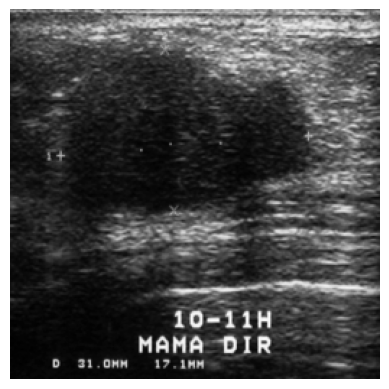

In [ ]:
plt.imshow(img[0, :, :], cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

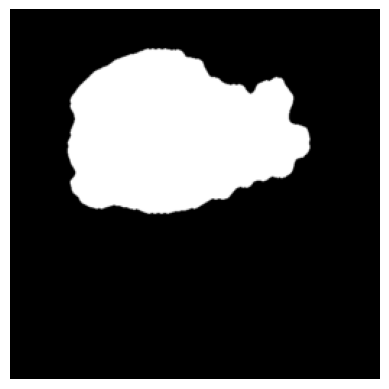

In [ ]:
plt.imshow(mask[0, :, :], cmap='gray')
plt.axis('off')

In [ ]:
print(img.size(), img.ndim, img.shape)
print(mask.size(), mask.ndim, img.shape)

torch.Size([3, 256, 256]) 3 torch.Size([3, 256, 256])
torch.Size([1, 256, 256]) 3 torch.Size([3, 256, 256])


In [ ]:
# #Convert augmented images to Datafram and concatenate
# df_augmented = pd.DataFrame(augmented_data)
# df_all = pd.concat([df, df_augmented], ignore_index=True)

SPLIT INTO TRAIN, TEST AND VALIDATE

No Augmentation done

In [ ]:
def generate_yolo_labels_and_splits(df, output_dir="yolo_dataset"):
    """
    Generate YOLO-format labels and split dataset into train/val/test

    Args:
    df: DataFrame with columns ['ID', 'Pathology', 'BBOX', 'Image_path']
    output_dir: Directory to save the organized dataset
    """

    print(f"Using original dataset only: {len(df)} samples")

    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(f"{output_dir}/labels/train", exist_ok=True)
    os.makedirs(f"{output_dir}/labels/val", exist_ok=True)
    os.makedirs(f"{output_dir}/labels/test", exist_ok=True)

    # Class mapping
    class_map = {'benign': 0, 'malignant': 1}

    # Add class_id column
    df['class_id'] = df['Pathology'].map(class_map)

    # Split dataset: 70% train, 15% val, 15% test
    train_df, temp_df = train_test_split(
        df, test_size=0.3, random_state=42, stratify=df['Pathology']
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, random_state=42, stratify=temp_df['Pathology']
    )

    def convert_bbox_to_yolo(bbox, img_width, img_height):
        """Convert BBOX to YOLO format"""
        x_min, y_min, width, height = bbox
        x_center = (x_min + width / 2) / img_width
        y_center = (y_min + height / 2) / img_height
        norm_width = width / img_width
        norm_height = height / img_height
        return x_center, y_center, norm_width, norm_height

    def save_yolo_labels(df_split, split_name):
        """Save YOLO labels for a dataset split"""
        split_dir = f"{output_dir}/labels/{split_name}"

        for idx, row in df_split.iterrows():
            try:
                # Load image to get dimensions
                img = Image.open(row['Image_path'])
                img_width, img_height = img.size

                # Convert BBOX to YOLO format
                x_center, y_center, norm_width, norm_height = convert_bbox_to_yolo(
                    row['BBOX'], img_width, img_height
                )

                # Create label filename
                image_filename = os.path.basename(row['Image_path'])
                label_filename = os.path.splitext(image_filename)[0] + ".txt"
                label_path = os.path.join(split_dir, label_filename)

                # Write YOLO label
                with open(label_path, "w") as f:
                    yolo_line = f"{row['class_id']} {x_center:.6f} {y_center:.6f} {norm_width:.6f} {norm_height:.6f}\n"
                    f.write(yolo_line)

            except Exception as e:
                print(f"Error processing {row.get('ID', 'unknown')}: {e}")

    # Save labels
    print("\nGenerating YOLO labels...")
    save_yolo_labels(train_df, "train")
    save_yolo_labels(val_df, "val")
    save_yolo_labels(test_df, "test")

    # Summary
    print(f"\nDataset Split Summary:")
    print(f"Total samples: {len(df)}")
    print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"Val: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

    print(f"\nClass distribution:")
    print("Train:")
    print(train_df['Pathology'].value_counts())
    print("Val:")
    print(val_df['Pathology'].value_counts())
    print("Test:")
    print(test_df['Pathology'].value_counts())

    # Create dataset.yaml file
    yaml_content = f"""# BUS-BRA Breast Cancer Dataset
path: {output_dir}
train: labels/train
val: labels/val
test: labels/test

# Classes
nc: 2
names: ['benign', 'malignant']
"""

    with open(f"{output_dir}/dataset.yaml", "w") as f:
        f.write(yaml_content)

    print(f"\nFiles created:")
    print(f"- {output_dir}/labels/train/ ({len(train_df)} .txt files)")
    print(f"- {output_dir}/labels/val/ ({len(val_df)} .txt files)")
    print(f"- {output_dir}/labels/test/ ({len(test_df)} .txt files)")
    print(f"- {output_dir}/dataset.yaml")

    return train_df, val_df, test_df, df

    print('Debug')


MODEL

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 39.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
%%writefile /content/drive/MyDrive/BUSBRA/libraries.py

import os
import glob
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')


import torch
import torch.optim as optim
import torch.nn as nn
from torch.nn import Sequential, Conv2d, BatchNorm2d, ModuleList, Upsample, SiLU
import torch.nn.functional as F

from torch.utils.data import DataLoader,Dataset
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
import torchvision.transforms.v2.functional as F
from torchvision.io import decode_image
from torchvision.utils import save_image


import albumentations as A
from albumentations.pytorch import ToTensorV2

from ultralytics import YOLO

Writing /content/drive/MyDrive/BUSBRA/libraries.py


In [ ]:
%run -i /content/drive/MyDrive/BUSBRA/libraries.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


<Figure size 640x480 with 0 Axes>

YOLOV9e

In [ ]:
# Build a YOLOv9e model from scratch
model = YOLO("yolov9e.yaml")

In [ ]:
model.info()

YOLOv9e summary: 721 layers, 58,206,592 parameters, 58,206,576 gradients, 193.0 GFLOPs


(721, 58206592, 58206576, 193.01565439999996)

MODEL

In [ ]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Identity()
      (1): Conv(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (3): RepNCSPELAN4(
        (cv1): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Sequential(
          (0): RepCSP(
            (cv1): Conv(
              (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias

In [ ]:
def analyze_yolov9_structure(model):
    """
    Analyze and separate the YOLOv9 model into backbone, neck, and detection head components.

    Args:
        model: The YOLOv9 model to analyze

    Returns:
        dict: Dictionary containing the separated components with their layers
    """
    # Initialize components
    components = {
        'backbone': {'description': 'Feature extraction layers', 'layers': []},
        'neck': {'description': 'Feature fusion and upsampling layers', 'layers': []},
        'head': {'description': 'Detection prediction layers', 'layers': []}
    }

    # Get the sequential model containing all layers
    sequential_model = model.model.model

    # Define layer indices for each component (may need adjustment based on specific architecture)
    backbone_end = 29  # Last layer of backbone (SPPELAN)
    neck_end = 41      # Last layer before detection head

    # Iterate through all layers and categorize them
    for i, layer in enumerate(sequential_model):
        layer_name = f"{i}: {layer.__class__.__name__}"

        if i <= backbone_end:
            components['backbone']['layers'].append(layer_name)
        elif i <= neck_end:
            components['neck']['layers'].append(layer_name)
        else:
            components['head']['layers'].append(layer_name)

    return components

def print_model_components(components):
    """Print the model components in a formatted way"""
    print("="*80)
    print("YOLOv9 Architecture Breakdown".center(80))
    print("="*80)

    for component, data in components.items():
        print(f"\n{component.upper()} ({data['description']})")
        print("-"*50)
        for i, layer in enumerate(data['layers']):
            print(layer)
        print(f"Total {component} layers: {len(data['layers'])}")

# Example usage:
if __name__ == "__main__":
    # Assuming you have your YOLOv9 model loaded as 'model'
    components = analyze_yolov9_structure(model)
    print_model_components(components)

                         YOLOv9 Architecture Breakdown                          

BACKBONE (Feature extraction layers)
--------------------------------------------------
0: Identity
1: Conv
2: Conv
3: RepNCSPELAN4
4: ADown
5: RepNCSPELAN4
6: ADown
7: RepNCSPELAN4
8: ADown
9: RepNCSPELAN4
10: CBLinear
11: CBLinear
12: CBLinear
13: CBLinear
14: CBLinear
15: Conv
16: CBFuse
17: Conv
18: CBFuse
19: RepNCSPELAN4
20: ADown
21: CBFuse
22: RepNCSPELAN4
23: ADown
24: CBFuse
25: RepNCSPELAN4
26: ADown
27: CBFuse
28: RepNCSPELAN4
29: SPPELAN
Total backbone layers: 30

NECK (Feature fusion and upsampling layers)
--------------------------------------------------
30: Upsample
31: Concat
32: RepNCSPELAN4
33: Upsample
34: Concat
35: RepNCSPELAN4
36: ADown
37: Concat
38: RepNCSPELAN4
39: ADown
40: Concat
41: RepNCSPELAN4
Total neck layers: 12

HEAD (Detection prediction layers)
--------------------------------------------------
42: Detect
Total head layers: 1


In [ ]:
def analyze_yolov9_architecture(model):
    """
    Analyze and separate the complete YOLOv9 architecture into backbone, neck, and head components
    with detailed hierarchical structure.

    Args:
        model: The YOLOv9 model (YOLO class instance from ultralytics)

    Returns:
        dict: Dictionary containing the separated components with their hierarchical layers
    """
    # Define component transition points (layer indices)
    BACKBONE_END = 29  # Last layer of backbone (SPPELAN)
    NECK_END = 41      # Last layer of neck (before detection head)

    # Initialize components
    components = {
        'backbone': {
            'description': 'Feature extraction layers (input -> SPPELAN)',
            'layers': []
        },
        'neck': {
            'description': 'Feature fusion and upsampling layers',
            'layers': []
        },
        'head': {
            'description': 'Detection prediction layers',
            'layers': []
        }
    }

    current_component = 'backbone'

    # Get the main sequential model
    sequential_model = model.model.model

    # Helper function to format module information
    def format_module(module, name='', depth=0):
        indent = '    ' * depth
        arrow = '└── ' if depth > 0 else ''

        # Basic module info
        module_class = module.__class__.__name__
        module_info = f"{indent}{arrow}{name}: {module_class}"

        # Add parameter details for specific module types
        if isinstance(module, torch.nn.Conv2d):
            params = f"in={module.in_channels}, out={module.out_channels}, " \
                     f"k={module.kernel_size}, stride={module.stride}, " \
                     f"pad={module.padding}"
            module_info += f" ({params})"
        elif isinstance(module, torch.nn.BatchNorm2d):
            params = f"features={module.num_features}, eps={module.eps}, " \
                     f"momentum={module.momentum}"
            module_info += f" ({params})"

        return module_info

    # Recursive function to process modules
    def process_module(module, name='', depth=0, parent_index=None):
        # Determine current component based on parent index
        nonlocal current_component
        if parent_index is not None:
            if parent_index <= BACKBONE_END:
                current_component = 'backbone'
            elif parent_index <= NECK_END:
                current_component = 'neck'
            else:
                current_component = 'head'

        # Format the current module
        module_info = format_module(module, name, depth)
        components[current_component]['layers'].append(module_info)

        # Process child modules if they exist
        if hasattr(module, '_modules') and module._modules:
            for child_name, child_module in module._modules.items():
                process_module(child_module, child_name, depth+1, parent_index)

    # Process all top-level layers in the sequential model
    for i, (name, layer) in enumerate(sequential_model.named_children()):
        process_module(layer, name, 0, i)

    return components

def print_architecture(components):
    """Print the architecture in a well-formatted way"""
    print("="*80)
    print("YOLOv9 COMPLETE ARCHITECTURE BREAKDOWN".center(80))
    print("="*80)

    for component, data in components.items():
        print(f"\n{component.upper()} - {data['description']}")
        print("-"*80)
        for layer in data['layers']:
            print(layer)
        print(f"\nTotal {component} layers: {len(data['layers'])}")

    print("\n" + "="*80)
    print("ARCHITECTURE SUMMARY".center(80))
    print("="*80)
    for component, data in components.items():
        print(f"{component.upper():<10}: {len(data['layers']):>4} layers")
    print("="*80)

# Example usage:
if __name__ == "__main__":
    # Assuming you have your YOLOv9 model loaded
    # model = YOLO("yolov9e.yaml")  # Your model initialization

    # Analyze the architecture
    architecture = analyze_yolov9_architecture(model)

    # Print the results
    print_architecture(architecture)

                     YOLOv9 COMPLETE ARCHITECTURE BREAKDOWN                     

BACKBONE - Feature extraction layers (input -> SPPELAN)
--------------------------------------------------------------------------------
0: Identity
1: Conv
    └── conv: Conv2d (in=3, out=64, k=(3, 3), stride=(2, 2), pad=(1, 1))
    └── bn: BatchNorm2d (features=64, eps=0.001, momentum=0.03)
    └── act: SiLU
2: Conv
    └── conv: Conv2d (in=64, out=128, k=(3, 3), stride=(2, 2), pad=(1, 1))
    └── bn: BatchNorm2d (features=128, eps=0.001, momentum=0.03)
    └── act: SiLU
3: RepNCSPELAN4
    └── cv1: Conv
        └── conv: Conv2d (in=128, out=128, k=(1, 1), stride=(1, 1), pad=(0, 0))
        └── bn: BatchNorm2d (features=128, eps=0.001, momentum=0.03)
        └── act: SiLU
    └── cv2: Sequential
        └── 0: RepCSP
            └── cv1: Conv
                └── conv: Conv2d (in=64, out=32, k=(1, 1), stride=(1, 1), pad=(0, 0))
                └── bn: BatchNorm2d (features=32, eps=0.001, momentum=0.03)
 

In [ ]:
def freeze_backbone(model):
    """
    Freeze all the backbone layers of the YOLOv9 model.

    Args:
        model: The YOLOv9 model (YOLO class instance from ultralytics)
    """
    BACKBONE_END = 29  # Last index of backbone layer

    # Get the sequential model
    sequential_model = model.model.model

    # Loop through the backbone layers and freeze their parameters
    for i, layer in enumerate(sequential_model):
        if i <= BACKBONE_END:
            for param in layer.parameters():
                param.requires_grad = False

    print(f"Backbone layers up to index {BACKBONE_END} have been frozen.")

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov9e.pt")  # Load pretrained model or from config
freeze_backbone(model)

100%|██████████| 112M/112M [00:01<00:00, 117MB/s]


Backbone layers up to index 29 have been frozen.


In [ ]:
class Conv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001, momentum=0.03)
        self.act = nn.SiLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class RepCSP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = Conv(in_channels, out_channels, 3, 1, 1)
    def forward(self, x):
        return self.conv(x)

class RepNCSPELAN4(nn.Module):
    """Optimized for medical imaging with reduced channels"""
    def __init__(self, in_channels, out_channels, hidden_channels=None):
        super().__init__()
        hidden_channels = hidden_channels or out_channels // 2
        self.cv1 = Conv(in_channels, hidden_channels, 1, 1, 0)
        self.cv2 = nn.Sequential(
            RepCSP(hidden_channels, hidden_channels // 2),
            Conv(hidden_channels, hidden_channels, 3, 1, 1)
        )
        self.cv3 = nn.Sequential(
            RepCSP(hidden_channels, hidden_channels // 2),
            Conv(hidden_channels, hidden_channels, 3, 1, 1)
        )
        self.cv4 = Conv(hidden_channels * 4, out_channels, 1, 1, 0)
    def forward(self, x):
        y1 = self.cv1(x)
        y2 = self.cv2(y1)
        y3 = self.cv3(y1 + y2)
        return self.cv4(torch.cat([y1, y2, y3, y1 + y2 + y3], 1))

class ADown(nn.Module):
    """Channel-preserving downsampling for medical features"""
    def __init__(self, channels):
        super().__init__()
        self.cv1 = Conv(channels, channels, 3, 2, 1)
        self.cv2 = Conv(channels, channels, 1, 1, 0)
    def forward(self, x):
        return self.cv2(self.cv1(x))

class SPPELAN(nn.Module):
    """Spatial Pyramid Pooling optimized for ultrasound features"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hidden = out_channels
        self.cv1 = Conv(in_channels, hidden, 1, 1, 0)
        self.cv2 = nn.ModuleList([
            nn.MaxPool2d(5, 1, 2),
            nn.MaxPool2d(5, 1, 2),
            nn.MaxPool2d(5, 1, 2)
        ])
        self.cv3 = Conv(hidden * 4, out_channels, 1, 1, 0)
    def forward(self, x):
        x = self.cv1(x)
        return self.cv3(torch.cat([x] + [m(x) for m in self.cv2], 1))

class UltrasoundNeck(nn.Module):
    """Optimized YOLOv9 neck for ultrasound image analysis"""
    def __init__(self, feature_channels=[512, 256, 128]):
        super().__init__()
        self.feat_channels = feature_channels
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.top_down_blocks = nn.ModuleList([
            RepNCSPELAN4(feature_channels[0] + feature_channels[1], feature_channels[1]),
            RepNCSPELAN4(feature_channels[1] + feature_channels[2], feature_channels[2])
        ])
        self.downsample_blocks = nn.ModuleList([
            ADown(feature_channels[2]),
            ADown(feature_channels[1])
        ])
        self.bottom_up_blocks = nn.ModuleList([
            RepNCSPELAN4(feature_channels[1] * 2, feature_channels[1]),
            RepNCSPELAN4(feature_channels[0] * 2, feature_channels[0])
        ])
        self.enhance_blocks = nn.ModuleList([
            SPPELAN(feature_channels[0], feature_channels[0] // 2),
            RepNCSPELAN4(feature_channels[1], feature_channels[1] // 2),
            RepNCSPELAN4(feature_channels[2], feature_channels[2] // 2)
        ])
        self.out_channels = [
            feature_channels[2] // 2,  # P3
            feature_channels[1] // 2,  # P4
            feature_channels[0] // 2   # P5
        ]
    def forward(self, features):
        p5, p4, p3 = features
        up5 = self.upsample(p5)
        merge_p4 = torch.cat([up5, p4], 1)
        td_p4 = self.top_down_blocks[0](merge_p4)
        up4 = self.upsample(td_p4)
        merge_p3 = torch.cat([up4, p3], 1)
        td_p3 = self.top_down_blocks[1](merge_p3)
        down_p3 = self.downsample_blocks[0](td_p3)
        merge_p4 = torch.cat([down_p3, td_p4], 1)
        bu_p4 = self.bottom_up_blocks[0](merge_p4)
        down_p4 = self.downsample_blocks[1](bu_p4)
        merge_p5 = torch.cat([down_p4, p5], 1)
        bu_p5 = self.bottom_up_blocks[1](merge_p5)
        enhanced_p5 = self.enhance_blocks[0](bu_p5)
        enhanced_p4 = self.enhance_blocks[1](bu_p4)
        enhanced_p3 = self.enhance_blocks[2](td_p3)
        return [enhanced_p3, enhanced_p4, enhanced_p5]

In [ ]:
class Conv(nn.Module):
    """Basic Conv block with Conv2d, BatchNorm and activation"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = BatchNorm2d(out_channels, eps=0.001, momentum=0.03)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class DFL(nn.Module):
    """Distribution Focal Loss module from YOLOv8"""
    def __init__(self, ch=16):
        super().__init__()
        self.conv = Conv2d(ch, 1, 1, bias=False)
        self.ch = ch

    def forward(self, x):
        b, c, h, w = x.shape
        x = x.view(b, 4, self.ch, h, w)
        x = self.conv(x)
        return x.view(b, 4, h, w)

class DetectHead(nn.Module):
    def __init__(self, in_channels=(64, 128, 256), num_classes=2):
        super().__init__()
        self.num_classes = num_classes
        self.num_outputs = num_classes + 5  # 2 classes + 4 box coords + 1 objectness

        # For box regression
        self.cv2 = ModuleList()
        for ch in in_channels:
            self.cv2.append(Sequential(
                Conv(ch, 64, 3, 1, 1),
                Conv(64, 64, 3, 1, 1),
                Conv2d(64, 4, 1)  # 4 outputs for box coordinates
            ))

        # For class confidence scores
        self.cv3 = ModuleList()
        for ch in in_channels:
            self.cv3.append(Sequential(
                Conv(ch, 256, 3, 1, 1),
                Conv(256, 256, 3, 1, 1),
                Conv2d(256, num_classes, 1)  # num_classes outputs
            ))

        # For objectness score
        self.obj = ModuleList()
        for ch in in_channels:
            self.obj.append(Sequential(
                Conv(ch, 64, 3, 1, 1),
                Conv2d(64, 1, 1)
            ))

        # DFL module (optional, not used in forward here)
        self.dfl = DFL(16)

    def forward(self, x):
        outputs = []
        for i, (cv2_layer, cv3_layer, obj_layer) in enumerate(zip(self.cv2, self.cv3, self.obj)):
            # Process box coordinates
            box_out = cv2_layer(x[i])
            # Process class scores
            cls_out = cv3_layer(x[i])
            # Process objectness
            obj_out = obj_layer(x[i])
            # Combine outputs: [4 box, 1 obj, 2 class] = 7 channels
            output = torch.cat([box_out, obj_out, cls_out], dim=1)
            outputs.append(output)
        return outputs

# Example usage:
if __name__ == "__main__":
    # Input features from neck at different scales
    features = [
        torch.randn(1, 64, 80, 80),   # Example feature map 1
        torch.randn(1, 128, 40, 40),  # Example feature map 2
        torch.randn(1, 256, 20, 20)   # Example feature map 3
    ]

    # Create detection head
    head = DetectHead(num_classes=2)

    # Forward pass
    outputs = head(features)
    for i, out in enumerate(outputs):
        print(f"Output {i+1} shape: {out.shape}")  # Should be [1, 7, H, W] (4 box + 1 obj + 2 class)

Output 1 shape: torch.Size([1, 7, 80, 80])
Output 2 shape: torch.Size([1, 7, 40, 40])
Output 3 shape: torch.Size([1, 7, 20, 20])


NSOYINE CODES

In [ ]:
# Check if yolo_dataset exists
if not os.path.exists("/content/drive/MyDrive/BUSBRA/yolo_dataset"):
    print("Generating yolo_dataset...")
    train_df, val_df, test_df, df_all = generate_yolo_labels_and_splits(
        df,

        output_dir="/content/drive/MyDrive/BUSBRA/yolo_dataset"
    )
else:
    print("yolo_dataset already exists")

Generating yolo_dataset...
Using original dataset only: 1214 samples

Generating YOLO labels...

Dataset Split Summary:
Total samples: 1214
Train: 849 (69.9%)
Val: 182 (15.0%)
Test: 183 (15.1%)

Class distribution:
Train:
Pathology
malignant    425
benign       424
Name: count, dtype: int64
Val:
Pathology
benign       91
malignant    91
Name: count, dtype: int64
Test:
Pathology
benign       92
malignant    91
Name: count, dtype: int64

Files created:
- /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train/ (849 .txt files)
- /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val/ (182 .txt files)
- /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/test/ (183 .txt files)
- /content/drive/MyDrive/BUSBRA/yolo_dataset/dataset.yaml


In [ ]:
# def create_symlinks_safely(df_split, split_name):
#     """Create symlinks while handling existing files"""
#     dest_dir = f"/content/drive/MyDrive/BUSBRA/yolo_dataset/images/{split_name}"
#     os.makedirs(dest_dir, exist_ok=True)

#     for img_path in df_split['Image_path']:
#         src = str(img_path)
#         dst = os.path.join(dest_dir, os.path.basename(src))

#         # Remove existing file/link if different from source
#         if os.path.exists(dst):
#             if not os.path.samefile(src, dst):
#                 os.remove(dst)
#             else:
#                 continue

#         try:
#             os.symlink(src, dst)
#         except FileExistsError:
#             continue
#         except Exception as e:
#             print(f"Error creating symlink for {src}: {str(e)}")

# # Create symlinks for all splits
# create_symlinks_safely(train_df, "train")
# create_symlinks_safely(val_df, "val")
# create_symlinks_safely(test_df, "test")

# print("Symlinks created successfully!")

import shutil

def create_copies_safely(df_split, split_name):
   """Create copies instead of symlinks"""
   dest_dir = f"/content/drive/MyDrive/BUSBRA/yolo_dataset/images/{split_name}"
   os.makedirs(dest_dir, exist_ok=True)

   copied_count = 0
   for img_path in df_split['Image_path']:
       src = str(img_path)
       dst = os.path.join(dest_dir, os.path.basename(src))

       if not os.path.exists(dst):
           try:
               shutil.copy2(src, dst)
               copied_count += 1
           except Exception as e:
               print(f"Error copying {src}: {str(e)}")

   print(f"Successfully copied {copied_count} images to {split_name} folder")

# Create copies for all splits
create_copies_safely(train_df, "train")
create_copies_safely(val_df, "val")
create_copies_safely(test_df, "test")

print("All image copies created successfully!")

Successfully copied 849 images to train folder
Successfully copied 182 images to val folder
Successfully copied 183 images to test folder
All image copies created successfully!


In [ ]:
# Check counts match
print(f"Train images: {len(os.listdir('/content/drive/MyDrive/BUSBRA/yolo_dataset/images/train'))} (expected {len(train_df)})")
print(f"Val images: {len(os.listdir('/content/drive/MyDrive/BUSBRA/yolo_dataset/images/val'))} (expected {len(val_df)})")
print(f"Test images: {len(os.listdir('/content/drive/MyDrive/BUSBRA/yolo_dataset/images/test'))} (expected {len(test_df)})")

# Sample check
sample_image = os.listdir('/content/drive/MyDrive/BUSBRA/yolo_dataset/images/train')[0]
print(f"\nSample image check: {os.path.exists(os.path.join('/content/drive/MyDrive/BUSBRA/yolo_dataset/images/train', sample_image))}")

Train images: 849 (expected 849)
Val images: 182 (expected 182)
Test images: 183 (expected 183)

Sample image check: True


In [ ]:
import os
from pathlib import Path

def check_directory_structure():
    base_path = "/content/drive/MyDrive/BUSBRA/yolo_dataset"
    required_dirs = {
        'images': ['train', 'val', 'test'],
        'labels': ['train', 'val', 'test']
    }

    print("Current directory structure:")
    for root, dirs, files in os.walk(base_path):
        level = root.replace(base_path, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files[:3]:  # Show first 3 files
            print(f"{subindent}{f}")
        if len(files) > 3:
            print(f"{subindent}... ({len(files)} total files)")

    # Verify required directories
    missing = []
    for main_dir, sub_dirs in required_dirs.items():
        for sub_dir in sub_dirs:
            path = os.path.join(base_path, main_dir, sub_dir)
            if not os.path.exists(path):
                missing.append(path)

    if missing:
        print("\n Missing directories:")
        for path in missing:
            print(f"- {path}")
    else:
        print("\n All required directories exist")

check_directory_structure()

Current directory structure:
yolo_dataset/
    dataset.yaml
    labels/
        train/
            bus_0001-l.txt
            bus_0578-l.txt
            bus_0685-l.txt
            ... (849 total files)
        val/
            bus_0797-s.txt
            bus_0222-r.txt
            bus_0005-l.txt
            ... (182 total files)
        test/
            bus_0216-r.txt
            bus_0252-r.txt
            bus_0426-l.txt
            ... (183 total files)
    images/
        train/
            bus_0001-l.png
            bus_0578-l.png
            bus_0685-l.png
            ... (849 total files)
        val/
            bus_0797-s.png
            bus_0222-r.png
            bus_0005-l.png
            ... (182 total files)
        test/
            bus_0216-r.png
            bus_0252-r.png
            bus_0426-l.png
            ... (183 total files)

 All required directories exist


In [ ]:
# Update dataset.yaml to use absolute paths
yaml_content = f"""path: /content/drive/MyDrive/BUSBRA/yolo_dataset
train: /content/drive/MyDrive/BUSBRA/yolo_dataset/images/train
val: /content/drive/MyDrive/BUSBRA/yolo_dataset/images/val
test: /content/drive/MyDrive/BUSBRA/yolo_dataset/images/test

train_labels: /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train
val_labels: /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val
test_labels: /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/test

names:
  0: benign
  1: malignant
"""

with open("/content/drive/MyDrive/BUSBRA/yolo_dataset/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("Updated dataset.yaml with absolute paths")

Updated dataset.yaml with absolute paths


In [ ]:
def verify_image_label_pairs():
    splits = ['train', 'val', 'test']
    issues = 0

    for split in splits:
        image_dir = f"/content/drive/MyDrive/BUSBRA/yolo_dataset/images/{split}"
        label_dir = f"/content/drive/MyDrive/BUSBRA/yolo_dataset/labels/{split}"

        # Get base filenames without extensions
        image_files = {Path(f).stem for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))}
        label_files = {Path(f).stem for f in os.listdir(label_dir) if f.endswith('.txt')}

        # Check for mismatches
        missing_images = label_files - image_files
        missing_labels = image_files - label_files

        if missing_images:
            print(f" {split}: {len(missing_images)} labels missing corresponding images")
            issues += len(missing_images)
        if missing_labels:
            print(f" {split}: {len(missing_labels)} images missing corresponding labels")
            issues += len(missing_labels)

    if issues == 0:
        print(" All image-label pairs match correctly")
    else:
        print(f"Total issues found: {issues}")

verify_image_label_pairs()

 All image-label pairs match correctly


In [ ]:
# from ultralytics import YOLO
# import torch
# from tqdm import tqdm
# import gc
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# from pathlib import Path
# import seaborn as sns
# from sklearn.metrics import confusion_matrix
# import yaml

# # Initialize model
# model = YOLO("/content/drive/MyDrive/BUSBRA/yolov9e.pt")

# # Enhanced Training Configuration with more plotting options
# train_params = {
#     'data': '/content/drive/MyDrive/BUSBRA/yolo_dataset/dataset.yaml',
#     'epochs': 3,
#     'batch': 8,
#     'imgsz': 640,
#     'device': '0',
#     'project': 'breast_cancer',
#     'name': 'yolov9e_final',
#     'exist_ok': True,
#     'freeze': 5,
#     'lr0': 1e-3,
#     'lrf': 1e-5,
#     'augment': True,
#     'mosaic': 0.5,
#     'mixup': 0.1,
#     'hsv_h': 0.02,
#     'hsv_s': 0.6,
#     'hsv_v': 0.4,
#     'val': True,
#     'workers': 2,
#     'patience': 10,
#     'save_period': 1,
#     'plots': True,  # Enable all default plots
#     'amp': True,
#     'optimizer': 'AdamW'
# }

# # Track metrics for custom plotting
# training_history = {
#     'epoch': [],
#     'train_loss': [],
#     'val_loss': [],
#     'mAP50': [],
#     'mAP50_95': [],
#     'precision': [],
#     'recall': [],
#     'f1': [],
#     'malignant_recall': [],
#     'malignant_precision': [],
#     'benign_recall': [],
#     'benign_precision': [],
#     'box_loss': [],
#     'cls_loss': []
# }

# best_metrics = {
#     'mAP50': 0,
#     'mAP50_95': 0,
#     'f1': 0,
#     'malignant_recall': 0
# }

# epoch_bar = tqdm(total=train_params['epochs'], desc="Training", unit='epoch')

# def plot_custom_metrics(save_dir):
#     """Create custom plots for breast cancer detection"""
#     fig, axes = plt.subplots(3, 3, figsize=(20, 15))
#     fig.suptitle('Breast Cancer Detection Training Metrics', fontsize=16)

#     epochs = training_history['epoch']

#     # Loss curves
#     axes[0, 0].plot(epochs, training_history['train_loss'], 'b-', label='Train Loss', linewidth=2)
#     axes[0, 0].plot(epochs, training_history['val_loss'], 'r-', label='Val Loss', linewidth=2)
#     axes[0, 0].set_title('Training & Validation Loss')
#     axes[0, 0].set_xlabel('Epoch')
#     axes[0, 0].set_ylabel('Loss')
#     axes[0, 0].legend()
#     axes[0, 0].grid(True, alpha=0.3)

#     # mAP curves
#     axes[0, 1].plot(epochs, training_history['mAP50'], 'g-', label='mAP@0.5', linewidth=2)
#     axes[0, 1].plot(epochs, training_history['mAP50_95'], 'orange', label='mAP@0.5:0.95', linewidth=2)
#     axes[0, 1].set_title('Mean Average Precision')
#     axes[0, 1].set_xlabel('Epoch')
#     axes[0, 1].set_ylabel('mAP')
#     axes[0, 1].legend()
#     axes[0, 1].grid(True, alpha=0.3)

#     # Precision & Recall
#     axes[0, 2].plot(epochs, training_history['precision'], 'purple', label='Overall Precision', linewidth=2)
#     axes[0, 2].plot(epochs, training_history['recall'], 'brown', label='Overall Recall', linewidth=2)
#     axes[0, 2].plot(epochs, training_history['f1'], 'pink', label='F1-Score', linewidth=2)
#     axes[0, 2].set_title('Overall Performance Metrics')
#     axes[0, 2].set_xlabel('Epoch')
#     axes[0, 2].set_ylabel('Score')
#     axes[0, 2].legend()
#     axes[0, 2].grid(True, alpha=0.3)

#     # Malignant vs Benign Recall
#     axes[1, 0].plot(epochs, training_history['malignant_recall'], 'red', label='Malignant Recall', linewidth=2)
#     axes[1, 0].plot(epochs, training_history['benign_recall'], 'blue', label='Benign Recall', linewidth=2)
#     axes[1, 0].set_title('Class-Specific Recall')
#     axes[1, 0].set_xlabel('Epoch')
#     axes[1, 0].set_ylabel('Recall')
#     axes[1, 0].legend()
#     axes[1, 0].grid(True, alpha=0.3)

#     # Malignant vs Benign Precision
#     axes[1, 1].plot(epochs, training_history['malignant_precision'], 'red', label='Malignant Precision', linewidth=2)
#     axes[1, 1].plot(epochs, training_history['benign_precision'], 'blue', label='Benign Precision', linewidth=2)
#     axes[1, 1].set_title('Class-Specific Precision')
#     axes[1, 1].set_xlabel('Epoch')
#     axes[1, 1].set_ylabel('Precision')
#     axes[1, 1].legend()
#     axes[1, 1].grid(True, alpha=0.3)

#     # Learning progress (combined metric)
#     combined_score = np.array(training_history['mAP50_95']) * 0.5 + np.array(training_history['malignant_recall']) * 0.5
#     axes[1, 2].plot(epochs, combined_score, 'green', label='Combined Score', linewidth=2)
#     axes[1, 2].set_title('Combined Performance Score\n(mAP50-95 × 0.5 + Malignant Recall × 0.5)')
#     axes[1, 2].set_xlabel('Epoch')
#     axes[1, 2].set_ylabel('Score')
#     axes[1, 2].legend()
#     axes[1, 2].grid(True, alpha=0.3)

#     # Box and Class Loss (from original script)
#     axes[2, 0].plot(epochs, training_history['box_loss'], 'orange', label='Box Loss', linewidth=2)
#     axes[2, 0].plot(epochs, training_history['cls_loss'], 'red', label='Class Loss', linewidth=2)
#     axes[2, 0].set_title('Training Losses Breakdown')
#     axes[2, 0].set_xlabel('Epoch')
#     axes[2, 0].set_ylabel('Loss')
#     axes[2, 0].legend()
#     axes[2, 0].grid(True, alpha=0.3)

#     # Learning Rate Schedule
#     if 'lr' in training_history and training_history['lr']:
#         axes[2, 1].plot(epochs, training_history['lr'], 'purple', label='Learning Rate', linewidth=2)
#         axes[2, 1].set_title('Learning Rate Schedule')
#         axes[2, 1].set_xlabel('Epoch')
#         axes[2, 1].set_ylabel('Learning Rate')
#         axes[2, 1].legend()
#         axes[2, 1].grid(True, alpha=0.3)
#     else:
#         axes[2, 1].axis('off')

#     # Memory Usage
#     if 'memory' in training_history and training_history['memory']:
#         axes[2, 2].plot(epochs, training_history['memory'], 'gray', label='GPU Memory (GB)', linewidth=2)
#         axes[2, 2].set_title('GPU Memory Usage')
#         axes[2, 2].set_xlabel('Epoch')
#         axes[2, 2].set_ylabel('Memory (GB)')
#         axes[2, 2].legend()
#         axes[2, 2].grid(True, alpha=0.3)
#     else:
#         axes[2, 2].axis('off')

#     plt.tight_layout()
#     plt.savefig(save_dir / 'custom_training_metrics.png', dpi=300, bbox_inches='tight')
#     plt.close()

# def plot_confusion_matrix(model, save_dir):
#     """Plot confusion matrix after validation (from original script)"""
#     try:
#         # Run validation to get confusion matrix
#         metrics = model.val(data=train_params['data'], batch=8, imgsz=640)

#         if hasattr(metrics, 'confusion_matrix') and metrics.confusion_matrix is not None:
#             cm = metrics.confusion_matrix.matrix

#             plt.figure(figsize=(8, 6))
#             sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                        xticklabels=['Background', 'Benign', 'Malignant'],
#                        yticklabels=['Background', 'Benign', 'Malignant'])
#             plt.xlabel('Predicted')
#             plt.ylabel('Actual')
#             plt.title('Confusion Matrix')
#             plt.savefig(save_dir / 'detailed_confusion_matrix.png', dpi=300, bbox_inches='tight')
#             plt.close()

#             print(f"Confusion matrix saved to {save_dir / 'detailed_confusion_matrix.png'}")

#     except Exception as e:
#         print(f"Could not generate confusion matrix: {e}")

# def create_inference_script(save_dir):
#     """Create inference script (from original script)"""
#     infer_py = '''from ultralytics import YOLO
# from pathlib import Path
# import argparse

# def detect(model_path, img_path, conf=0.25, device='0'):
#     """Run inference on breast cancer ultrasound images"""
#     model = YOLO(model_path)
#     results = model(img_path, conf=conf, device=device)

#     # Save results
#     save_dir = Path('infer_out')
#     save_dir.mkdir(exist_ok=True)

#     for i, result in enumerate(results):
#         result.save(save_dir / f'result_{i}.jpg')

#     print(f'Results saved to {save_dir}/')
#     return results

# def main():
#     parser = argparse.ArgumentParser(description='Breast Cancer Detection Inference')
#     parser.add_argument('--model', default='best.pt', help='Path to model weights')
#     parser.add_argument('--image', required=True, help='Path to input image or directory')
#     parser.add_argument('--conf', type=float, default=0.25, help='Confidence threshold')
#     parser.add_argument('--device', default='0', help='Device to run on (0 for GPU, cpu for CPU)')

#     args = parser.parse_args()

#     results = detect(args.model, args.image, args.conf, args.device)

#     # Print detection summary
#     for i, result in enumerate(results):
#         print(f"\\nImage {i+1} detections:")
#         boxes = result.boxes
#         if boxes is not None:
#             for box in boxes:
#                 conf = box.conf[0].item()
#                 cls = int(box.cls[0].item())
#                 class_name = result.names[cls]
#                 print(f"  - {class_name}: {conf:.3f}")
#         else:
#             print("  - No detections")

# if __name__ == '__main__':
#     main()
# '''

#     with open(save_dir / 'infer.py', 'w') as f:
#         f.write(infer_py)

#     print(f"Inference script saved to {save_dir / 'infer.py'}")

# def save_training_config(save_dir):
#     """Save training configuration for reproducibility"""
#     config = {
#         'model': 'yolov9e.pt',
#         'training_params': train_params,
#         'best_metrics': best_metrics,
#         'torch_version': torch.__version__,
#         'cuda_version': torch.version.cuda if torch.cuda.is_available() else 'N/A'
#     }

#     with open(save_dir / 'training_config.yaml', 'w') as f:
#         yaml.dump(config, f, default_flow_style=False)

#     print(f"Training configuration saved to {save_dir / 'training_config.yaml'}")

# def on_train_epoch_end(trainer):
#     global best_metrics, epoch_bar, training_history

#     torch.cuda.empty_cache()
#     gc.collect()

#     metrics = trainer.metrics
#     current_epoch = trainer.epoch + 1

#     # Extract metrics (enhanced from original)
#     train_loss = metrics.get('train/box_loss', 0) + metrics.get('train/cls_loss', 0)
#     val_loss = metrics.get('val/box_loss', 0) + metrics.get('val/cls_loss', 0)
#     box_loss = metrics.get('train/box_loss', 0)
#     cls_loss = metrics.get('train/cls_loss', 0)
#     mAP50 = metrics.get('metrics/mAP50(B)', 0)
#     mAP50_95 = metrics.get('metrics/mAP50-95(B)', 0)
#     precision = metrics.get('metrics/precision(B)', 0)
#     recall = metrics.get('metrics/recall(B)', 0)
#     f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

#     # Extract class-specific metrics
#     malignant_recall = 0
#     malignant_precision = 0
#     benign_recall = 0
#     benign_precision = 0

#     if hasattr(trainer.validator, 'metrics'):
#         val_metrics = trainer.validator.metrics
#         if hasattr(val_metrics, 'r') and len(val_metrics.r) >= 2:
#             benign_recall = val_metrics.r[0]
#             malignant_recall = val_metrics.r[1]
#         if hasattr(val_metrics, 'p') and len(val_metrics.p) >= 2:
#             benign_precision = val_metrics.p[0]
#             malignant_precision = val_metrics.p[1]

#     # Store metrics for plotting (enhanced)
#     training_history['epoch'].append(current_epoch)
#     training_history['train_loss'].append(train_loss)
#     training_history['val_loss'].append(val_loss)
#     training_history['box_loss'].append(box_loss)
#     training_history['cls_loss'].append(cls_loss)
#     training_history['mAP50'].append(mAP50)
#     training_history['mAP50_95'].append(mAP50_95)
#     training_history['precision'].append(precision)
#     training_history['recall'].append(recall)
#     training_history['f1'].append(f1)
#     training_history['malignant_recall'].append(malignant_recall)
#     training_history['malignant_precision'].append(malignant_precision)
#     training_history['benign_recall'].append(benign_recall)
#     training_history['benign_precision'].append(benign_precision)

#     # Track additional metrics
#     if not 'lr' in training_history:
#         training_history['lr'] = []
#     if not 'memory' in training_history:
#         training_history['memory'] = []

#     # Get current learning rate
#     current_lr = trainer.optimizer.param_groups[0]['lr']
#     training_history['lr'].append(current_lr)

#     # Get GPU memory usage
#     if torch.cuda.is_available():
#         memory_gb = torch.cuda.memory_reserved(0) / 1e9
#         training_history['memory'].append(memory_gb)
#     else:
#         training_history['memory'].append(0)

#     # Update progress
#     epoch_bar.set_postfix({
#         'mAP50': f"{mAP50:.3f}",
#         'mAP50-95': f"{mAP50_95:.3f}",
#         'F1': f"{f1:.3f}",
#         'Mal_Rec': f"{malignant_recall:.3f}",
#         'LR': f"{current_lr:.2e}",
#         'GPU': f"{memory_gb:.1f}GB" if torch.cuda.is_available() else "N/A"
#     })
#     epoch_bar.update(1)

#     # Save best model
#     if malignant_recall > best_metrics['malignant_recall'] or mAP50_95 > best_metrics['mAP50_95']:
#         best_metrics.update({
#             'mAP50': mAP50,
#             'mAP50_95': mAP50_95,
#             'f1': f1,
#             'malignant_recall': malignant_recall
#         })

#         ckpt_path = f"/content/drive/MyDrive/BUSBRA/best_model_epoch{current_epoch}.pt"
#         torch.save({
#             'epoch': current_epoch,
#             'model': trainer.ema.ema.state_dict(),
#             'metrics': best_metrics,
#             'training_history': training_history
#         }, ckpt_path)

#         tqdm.write(f"\nEpoch {current_epoch}: 🏆 New Best")
#         tqdm.write(f"Saved to: {ckpt_path}")
#         tqdm.write(f"mAP50-95: {mAP50_95:.3f} | Malignant Recall: {malignant_recall:.3f}")

#     # Generate plots every 5 epochs
#     if current_epoch % 5 == 0:
#         save_dir = Path(f"/content/drive/MyDrive/BUSBRA/breast_cancer/yolov9e_final")
#         save_dir.mkdir(parents=True, exist_ok=True)
#         plot_custom_metrics(save_dir)

# # Register callback
# model.add_callback("on_train_epoch_end", on_train_epoch_end)

# # Start training
# print(f" Starting optimized training with enhanced plotting...")
# try:
#     torch.backends.cudnn.benchmark = True
#     torch.cuda.empty_cache()
#     results = model.train(**train_params)

#     # Post-training analysis and exports (from original script)
#     save_dir = Path(f"/kaggle/working/breast_cancer/yolov9e_final")
#     save_dir.mkdir(parents=True, exist_ok=True)

#     # Generate final plots
#     plot_custom_metrics(save_dir)

#     # Generate confusion matrix
#     plot_confusion_matrix(model, save_dir)

#     # Save training history as CSV
#     df = pd.DataFrame(training_history)
#     df.to_csv(save_dir / 'training_history.csv', index=False)

#     # Create inference script
#     create_inference_script(save_dir)

#     # Save training configuration
#     save_training_config(save_dir)

#     # Export best model to ONNX (from original script)
#     print("\n Exporting model to ONNX format...")
#     best_model_path = Path(f"/content/drive/MyDrive/BUSBRA/best_model_epoch{len(training_history['epoch'])}.pt")
#     if best_model_path.exists():
#         # Load best model for export
#         best_model = YOLO(best_model_path)
#         onnx_path = save_dir / 'best_model.onnx'
#         best_model.export(format='onnx', imgsz=640, dynamic=False, simplify=True)
#         print(f" ONNX model exported to {onnx_path}")
#     else:
#         # Export current model
#         model.export(format='onnx', imgsz=640, dynamic=False, simplify=True)
#         print(" Current model exported to ONNX format")

#     # Final evaluation metrics (from original script)
#     print("\n Final Model Evaluation...")
#     final_metrics = model.val(data=train_params['data'], batch=8, imgsz=640)
#     print(f"Final mAP50: {final_metrics.box.map50:.4f}")
#     print(f"Final mAP50-95: {final_metrics.box.map:.4f}")
#     if hasattr(final_metrics.box, 'maps'):
#         print(f"Per-class mAP50-95: {final_metrics.box.maps}")

# finally:
#     epoch_bar.close()
#     print("\n Final Best Metrics")
#     print(f"mAP50:            {best_metrics['mAP50']:.3f}")
#     print(f"mAP50-95:         {best_metrics['mAP50_95']:.3f}")
#     print(f"F1-Score:         {best_metrics['f1']:.3f}")
#     print(f"Malignant Recall: {best_metrics['malignant_recall']:.3f}")

#     # Show available outputs
#     save_dir = Path(f"/content/drive/MyDrive/BUSBRA/breast_cancer/yolov9e_final")
#     print(f"\n Generated outputs saved to: {save_dir}")
#     print("Available files:")
#     print("- results.png (default YOLO training curves)")
#     print("- confusion_matrix.png (default classification performance)")
#     print("- detailed_confusion_matrix.png (enhanced confusion matrix)")
#     print("- val_batch*.jpg (validation predictions)")
#     print("- labels.jpg (dataset statistics)")
#     print("- custom_training_metrics.png (comprehensive training metrics)")
#     print("- training_history.csv (all metrics data)")
#     print("- training_config.yaml (training configuration)")
#     print("- infer.py (inference script)")
#     print("- best_model.onnx (exported model)")

#     print("\n Training pipeline completed successfully!")

In [ ]:
from glob import glob

malignant_labels = [f for f in glob('/content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train/*.txt')
                    if open(f).read().startswith('1')]
print(f"Number of malignant labels in training set: {len(malignant_labels)}")


Number of malignant labels in training set: 425


In [ ]:
from ultralytics import YOLO
import torch
from tqdm import tqdm
import gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import yaml
import cv2
from collections import defaultdict

# Initialize model
model = YOLO("/content/drive/MyDrive/BUSBRA/yolov9e.pt")

# Training Configuration
train_params = {
    'data': '/content/drive/MyDrive/BUSBRA/yolo_dataset/dataset.yaml',
    'epochs': 30,
    'batch': 8,
    'imgsz': 640,
    'device': '0',
    'project': 'breast_cancer',
    'name': 'yolov9e_final',
    'exist_ok': True,
    'freeze': 5,
    'lr0': 1e-3,
    'lrf': 1e-5,
    'augment': True,
    'mosaic': 0.5,
    'mixup': 0.1,
    'hsv_h': 0.02,
    'hsv_s': 0.6,
    'hsv_v': 0.4,
    'val': True,
    'workers': 2,
    'patience': 10,
    'save_period': 1,
    'plots': True,
    'amp': True,
    'optimizer': 'AdamW'
}

# Track metrics for plotting
training_history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'mAP50': [],
    'mAP50_95': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'box_loss': [],
    'cls_loss': [],
    'lr': [],
    'memory': []
}

best_metrics = {
    'mAP50': 0,
    'mAP50_95': 0,
    'f1': 0,
    'epoch': 0
}

def plot_custom_metrics(save_dir):
    """Create custom plots for training metrics"""
    if not training_history['epoch']:
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Breast Cancer Detection Training Metrics', fontsize=16)

    epochs = training_history['epoch']

    # Loss curves
    axes[0, 0].plot(epochs, training_history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, training_history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Training & Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # mAP curves
    axes[0, 1].plot(epochs, training_history['mAP50'], 'g-', label='mAP@0.5', linewidth=2)
    axes[0, 1].plot(epochs, training_history['mAP50_95'], 'orange', label='mAP@0.5:0.95', linewidth=2)
    axes[0, 1].set_title('Mean Average Precision')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('mAP')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Precision & Recall
    axes[0, 2].plot(epochs, training_history['precision'], 'purple', label='Precision', linewidth=2)
    axes[0, 2].plot(epochs, training_history['recall'], 'brown', label='Recall', linewidth=2)
    axes[0, 2].plot(epochs, training_history['f1'], 'pink', label='F1-Score', linewidth=2)
    axes[0, 2].set_title('Overall Performance Metrics')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Box and Class Loss
    axes[1, 0].plot(epochs, training_history['box_loss'], 'orange', label='Box Loss', linewidth=2)
    axes[1, 0].plot(epochs, training_history['cls_loss'], 'red', label='Class Loss', linewidth=2)
    axes[1, 0].set_title('Loss Components')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Learning Rate Schedule
    if training_history['lr']:
        axes[1, 1].plot(epochs, training_history['lr'], 'purple', label='Learning Rate', linewidth=2)
        axes[1, 1].set_title('Learning Rate Schedule')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].axis('off')

    # Memory Usage
    if training_history['memory']:
        axes[1, 2].plot(epochs, training_history['memory'], 'gray', label='GPU Memory (GB)', linewidth=2)
        axes[1, 2].set_title('GPU Memory Usage')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Memory (GB)')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    else:
        axes[1, 2].axis('off')

    plt.tight_layout()
    plt.savefig(save_dir / 'custom_training_metrics.png', dpi=300, bbox_inches='tight')
    plt.close()

def create_inference_script(save_dir):
    """Create inference script for the trained model"""
    inference_script = '''#!/usr/bin/env python3
"""
Breast Cancer Detection Inference Script
Usage: python infer.py --model best.pt --image path/to/image.jpg
"""

from ultralytics import YOLO
from pathlib import Path
import argparse
import cv2
import numpy as np

def detect_breast_cancer(model_path, img_path, conf=0.25, device='0'):
    """Run inference on breast cancer ultrasound images"""
    print(f"Loading model from: {model_path}")
    model = YOLO(model_path)

    print(f"Running inference on: {img_path}")
    results = model(img_path, conf=conf, device=device)

    # Create output directory
    save_dir = Path('inference_results')
    save_dir.mkdir(exist_ok=True)

    for i, result in enumerate(results):
        # Save annotated image
        annotated = result.plot()
        output_path = save_dir / f'result_{Path(img_path).stem}_{i}.jpg'
        cv2.imwrite(str(output_path), annotated)

        # Print results
        print(f"\\nResults for {result.path}:")
        print(f"Image size: {result.orig_shape}")

        if result.boxes is not None and len(result.boxes) > 0:
            print(f"Found {len(result.boxes)} detection(s):")
            for j, box in enumerate(result.boxes):
                conf = box.conf[0].item()
                cls = int(box.cls[0].item())
                class_name = result.names[cls]
                coords = box.xyxy[0].tolist()

                print(f"  Detection {j+1}:")
                print(f"    Class: {class_name}")
                print(f"    Confidence: {conf:.3f}")
                print(f"    Box: [x1={coords[0]:.1f}, y1={coords[1]:.1f}, x2={coords[2]:.1f}, y2={coords[3]:.1f}]")

                # Clinical interpretation
                if class_name.lower() == 'malignant':
                    risk_level = "HIGH RISK" if conf > 0.7 else "MODERATE RISK" if conf > 0.4 else "LOW RISK"
                    print(f"      MALIGNANT DETECTION - {risk_level}")
                else:
                    print(f"     BENIGN DETECTION")
        else:
            print("  No detections above confidence threshold")
            print("  No suspicious areas detected")

        print(f"\\nAnnotated image saved to: {output_path}")

    return results

def main():
    parser = argparse.ArgumentParser(description='Breast Cancer Detection Inference')
    parser.add_argument('--model', required=True, help='Path to trained model weights (.pt file)')
    parser.add_argument('--image', required=True, help='Path to input image or directory')
    parser.add_argument('--conf', type=float, default=0.25, help='Confidence threshold (0-1)')
    parser.add_argument('--device', default='0', help='Device to run on (0 for GPU, cpu for CPU)')

    args = parser.parse_args()

    # Validate inputs
    if not Path(args.model).exists():
        print(f"Error: Model file not found: {args.model}")
        return

    if not Path(args.image).exists():
        print(f"Error: Image file not found: {args.image}")
        return

    # Run inference
    try:
        results = detect_breast_cancer(args.model, args.image, args.conf, args.device)
        print("\\n Inference completed successfully!")
        print(" Clinical Notes:")
        print("- High confidence malignant detections should be reviewed by a radiologist")
        print("- This AI tool is for assistance only, not diagnosis")
        print("- Always correlate with clinical findings and patient history")

    except Exception as e:
        print(f" Error during inference: {e}")
        import traceback
        traceback.print_exc()

if __name__ == '__main__':
    main()
'''

    with open(save_dir / 'infer.py', 'w') as f:
        f.write(inference_script)

    print(f" Inference script saved to {save_dir / 'infer.py'}")

def save_training_config(save_dir):
    """Save training configuration for reproducibility"""
    config = {
        'model_architecture': 'yolov9e',
        'training_parameters': train_params,
        'best_metrics': best_metrics,
        'torch_version': torch.__version__,
        'cuda_available': torch.cuda.is_available(),
        'cuda_version': torch.version.cuda if torch.cuda.is_available() else 'N/A',
        'device_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
    }

    with open(save_dir / 'training_config.yaml', 'w') as f:
        yaml.dump(config, f, default_flow_style=False, indent=2)

    print(f" Training configuration saved to {save_dir / 'training_config.yaml'}")

# Progress tracking
epoch_bar = tqdm(total=train_params['epochs'], desc="Training Progress", unit='epoch')

def on_train_epoch_end(trainer):
    """Simplified epoch end callback"""
    global best_metrics, epoch_bar, training_history

    # Clean up memory
    torch.cuda.empty_cache()
    gc.collect()

    # Get metrics from trainer
    metrics = trainer.metrics
    current_epoch = trainer.epoch + 1

    # Extract key metrics
    train_loss = metrics.get('train/box_loss', 0) + metrics.get('train/cls_loss', 0)
    val_loss = metrics.get('val/box_loss', 0) + metrics.get('val/cls_loss', 0)
    box_loss = metrics.get('train/box_loss', 0)
    cls_loss = metrics.get('train/cls_loss', 0)
    mAP50 = metrics.get('metrics/mAP50(B)', 0)
    mAP50_95 = metrics.get('metrics/mAP50-95(B)', 0)
    precision = metrics.get('metrics/precision(B)', 0)
    recall = metrics.get('metrics/recall(B)', 0)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-16) if (precision + recall) > 0 else 0

    # Store metrics
    training_history['epoch'].append(current_epoch)
    training_history['train_loss'].append(train_loss)
    training_history['val_loss'].append(val_loss)
    training_history['box_loss'].append(box_loss)
    training_history['cls_loss'].append(cls_loss)
    training_history['mAP50'].append(mAP50)
    training_history['mAP50_95'].append(mAP50_95)
    training_history['precision'].append(precision)
    training_history['recall'].append(recall)
    training_history['f1'].append(f1)

    # Learning rate and memory
    current_lr = trainer.optimizer.param_groups[0]['lr']
    training_history['lr'].append(current_lr)

    if torch.cuda.is_available():
        memory_gb = torch.cuda.memory_reserved(0) / 1e9
        training_history['memory'].append(memory_gb)
    else:
        training_history['memory'].append(0)

    # Update progress bar
    epoch_bar.set_postfix({
        'mAP50': f"{mAP50:.3f}",
        'mAP50-95': f"{mAP50_95:.3f}",
        'Precision': f"{precision:.3f}",
        'Recall': f"{recall:.3f}",
        'F1': f"{f1:.3f}",
        'LR': f"{current_lr:.2e}"
    })
    epoch_bar.update(1)

    # Track best model
    is_best = mAP50_95 > best_metrics['mAP50_95']

    if is_best:
        best_metrics.update({
            'mAP50': mAP50,
            'mAP50_95': mAP50_95,
            'f1': f1,
            'epoch': current_epoch
        })

        tqdm.write(f"\n New Best Model - Epoch {current_epoch}")
        tqdm.write(f"mAP50: {mAP50:.3f} | mAP50-95: {mAP50_95:.3f} | F1: {f1:.3f}")

    # Generate plots periodically
    if current_epoch % max(1, train_params['epochs'] // 2) == 0:
        save_dir = Path(f"/content/drive/MyDrive/BUSBRA/breast_cancer/yolov9e_final")
        save_dir.mkdir(parents=True, exist_ok=True)
        plot_custom_metrics(save_dir)

# Register callback
model.add_callback("on_train_epoch_end", on_train_epoch_end)

# Start training
print(" Starting YOLO training for breast cancer detection...")
print(f" Training parameters:")
for key, value in train_params.items():
    print(f"  {key}: {value}")

try:
    # Optimize for training
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        torch.cuda.empty_cache()
        print(f" Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("  Using CPU - training will be slower")

    # Train the model
    results = model.train(**train_params)

    # Post-training analysis
    print("\n Training completed! Generating final analysis...")

    save_dir = Path(f"/content/drive/MyDrive/BUSBRA/breast_cancer/yolov9e_final")
    save_dir.mkdir(parents=True, exist_ok=True)

    # Final plots
    plot_custom_metrics(save_dir)

    # Save training history
    if training_history['epoch']:
        df = pd.DataFrame(training_history)
        df.to_csv(save_dir / 'training_history.csv', index=False)
        print(f" Training history saved to {save_dir / 'training_history.csv'}")

    # Create inference script
    create_inference_script(save_dir)

    # Save configuration
    save_training_config(save_dir)

    # Final validation
    print("\n Running final validation...")
    final_metrics = model.val(data=train_params['data'], batch=8, imgsz=640)

    print(f"\n Final Results:")
    print(f"  mAP50: {final_metrics.box.map50:.4f}")
    print(f"  mAP50-95: {final_metrics.box.map:.4f}")
    print(f"  Precision: {final_metrics.box.mp:.4f}")
    print(f"  Recall: {final_metrics.box.mr:.4f}")

    # Export model
    print("\n Exporting model to ONNX format...")
    try:
        onnx_path = model.export(format='onnx', imgsz=640, dynamic=False, simplify=True)
        print(f" Model exported to: {onnx_path}")
    except Exception as e:
        print(f" Export failed: {e}")

    print(f"\n Training completed successfully!")
    print(f" All outputs saved to: {save_dir}")

except Exception as e:
    print(f" Training failed: {e}")
    import traceback
    traceback.print_exc()

finally:
    epoch_bar.close()

    # Memory cleanup
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    print("\n Final Summary:")
    print(f"Best mAP50: {best_metrics['mAP50']:.3f}")
    print(f"Best mAP50-95: {best_metrics['mAP50_95']:.3f}")
    print(f"Best F1: {best_metrics['f1']:.3f}")
    print(f"Best epoch: {best_metrics['epoch']}")

    print("\n Generated Files:")
    print("- training_history.csv (metrics data)")
    print("- custom_training_metrics.png (training plots)")
    print("- training_config.yaml (configuration)")
    print("- infer.py (inference script)")
    print("- best.pt (trained model)")
    print("- best.onnx (exported model)")

    print("\n Next Steps:")
    print("1. Review the training plots in custom_training_metrics.png")
    print("2. Test the model using: python infer.py --model best.pt --image test_image.jpg")
    print("3. Adjust confidence threshold based on your clinical requirements")
    print("4. Consider additional training if performance is not satisfactory")

Training Progress:   0%|          | 0/30 [00:00<?, ?epoch/s]

 Starting YOLO training for breast cancer detection...
 Training parameters:
  data: /content/drive/MyDrive/BUSBRA/yolo_dataset/dataset.yaml
  epochs: 30
  batch: 8
  imgsz: 640
  device: 0
  project: breast_cancer
  name: yolov9e_final
  exist_ok: True
  freeze: 5
  lr0: 0.001
  lrf: 1e-05
  augment: True
  mosaic: 0.5
  mixup: 0.1
  hsv_h: 0.02
  hsv_s: 0.6
  hsv_v: 0.4
  val: True
  workers: 2
  patience: 10
  save_period: 1
  plots: True
  amp: True
  optimizer: AdamW
 Using GPU: Tesla T4
Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BUSBRA/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epo


train: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train...:   0%|          | 0/849 [00:00<?, ?it/s]
train: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train... 5 images, 0 backgrounds, 0 corrupt:   1%|          | 5/849 [00:02<07:01,  2.00it/s]
train: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train... 6 images, 0 backgrounds, 0 corrupt:   1%|          | 6/849 [00:03<09:09,  1.53it/s]
train: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train... 29 images, 0 backgrounds, 0 corrupt:   3%|▎         | 29/849 [00:03<01:07, 12.14it/s]
train: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train... 46 images, 0 backgrounds, 0 corrupt:   5%|▌         | 46/849 [00:03<00:36, 21.94it/s]
train: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train... 68 images, 0 backgrounds, 0 corrupt:   8%|▊         | 68/849 [00:03<00:20, 38.06it/s]
train: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train... 87 imag

train: New cache created: /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 1.8±2.4 ms, read: 18.7±22.3 MB/s, size: 81.3 KB)



val: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val...:   0%|          | 0/182 [00:00<?, ?it/s]
val: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val... 12 images, 0 backgrounds, 0 corrupt:   7%|▋         | 12/182 [00:00<00:01, 113.59it/s]
val: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val... 24 images, 0 backgrounds, 0 corrupt:  13%|█▎        | 24/182 [00:00<00:01, 80.49it/s] 
val: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val... 33 images, 0 backgrounds, 0 corrupt:  18%|█▊        | 33/182 [00:00<00:01, 77.28it/s]
val: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val... 41 images, 0 backgrounds, 0 corrupt:  23%|██▎       | 41/182 [00:00<00:01, 77.93it/s]
val: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val... 50 images, 0 backgrounds, 0 corrupt:  27%|██▋       | 50/182 [00:00<00:01, 81.19it/s]
val: Scanning /content/drive/MyDrive/BUSBRA/yolo_dataset/labels/val... 59 images, 0 backgrounds, 0 c

...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size



  0%|          | 0/107 [00:00<?, ?it/s]
      29/30      8.12G     0.7288     0.5308      1.071          8        640:   0%|          | 0/107 [00:00<?, ?it/s]
      29/30      8.12G     0.7288     0.5308      1.071          8        640:   1%|          | 1/107 [00:00<01:41,  1.05it/s]
      29/30      8.12G     0.7911     0.8136      1.183          8        640:   1%|          | 1/107 [00:01<01:41,  1.05it/s]
      29/30      8.12G     0.7911     0.8136      1.183          8        640:   2%|▏         | 2/107 [00:01<01:28,  1.19it/s]
      29/30      8.12G     0.8124     0.7987      1.311          8        640:   2%|▏         | 2/107 [00:02<01:28,  1.19it/s]
      29/30      8.12G     0.8124     0.7987      1.311          8        640:   3%|▎         | 3/107 [00:02<01:24,  1.22it/s]
      29/30      8.16G     0.7945     0.7631      1.273          8        640:   3%|▎         | 3/107 [00:03<01:24,  1.22it/s]
      29/30      8.16G     0.7945     0.7631      1.273          8        640:

                   all        182        182      0.783      0.868      0.897      0.667



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size



  0%|          | 0/107 [00:00<?, ?it/s]
      30/30      8.09G     0.6591     0.6977      1.192          8        640:   0%|          | 0/107 [00:00<?, ?it/s]
      30/30      8.09G     0.6591     0.6977      1.192          8        640:   1%|          | 1/107 [00:00<01:19,  1.33it/s]
      30/30      8.12G     0.6282     0.7419      1.155          8        640:   1%|          | 1/107 [00:01<01:19,  1.33it/s]
      30/30      8.12G     0.6282     0.7419      1.155          8        640:   2%|▏         | 2/107 [00:01<01:18,  1.34it/s]
      30/30      8.12G     0.6981     0.6943      1.195          8        640:   2%|▏         | 2/107 [00:02<01:18,  1.34it/s]
      30/30      8.12G     0.6981     0.6943      1.195          8        640:   3%|▎         | 3/107 [00:02<01:18,  1.32it/s]
      30/30      8.12G     0.7341     0.7192      1.207          8        640:   3%|▎         | 3/107 [00:03<01:18,  1.32it/s]
      30/30      8.12G     0.7341     0.7192      1.207          8        640:

In [ ]:
import shutil

# Path to final output directory
output_dir = "/content/breast_cancer/yolov9e_final"
zip_path = "/content/drive/MyDrive/BUSBRA/yolov9e_final_outputs.zip"

# Zip entire directory
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', output_dir)

print(f" Zipped successfully: {zip_path}")


 Zipped successfully: /content/drive/MyDrive/BUSBRA/yolov9e_final_outputs.zip


Training Pipeline-New